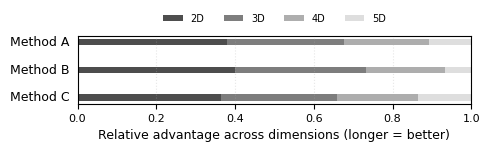

In [1]:
import numpy as np
import matplotlib.pyplot as plt

methods = ["Method A", "Method B", "Method C"]
dims = ["2D", "3D", "4D", "5D"]

# 示例：normalized latency (0~1, 越低越好)
data = np.array([
    [0.30, 0.45, 0.60, 0.80],  # A
    [0.40, 0.50, 0.70, 0.90],  # B
    [0.20, 0.35, 0.55, 0.70],  # C
])

fig, ax = plt.subplots(figsize=(5, 1.8))

n_methods, n_dims = data.shape
bar_height = 0.22
colors = ["#444444", "#777777", "#AAAAAA", "#DDDDDD"]

for i in range(n_methods):
    y = n_methods - 1 - i

    # 方法名
    ax.text(-0.02, y, methods[i], ha="right", va="center", fontsize=9)

    # 背景条（0-1范围）
    ax.barh(y, 1.0, height=bar_height, color="lightgray", alpha=0.25)

    # 这里做一个简单可解释策略：
    # 把 (1 - latency) 当作“好”的程度，按维度比例切成几段
    score = 1 - data[i]
    total = score.sum()
    if total <= 0:
        total = 1.0

    left = 0.0
    for j in range(n_dims):
        w = score[j] / total
        ax.barh(y, w, left=left, height=bar_height,
                color=colors[j], alpha=0.95,
                label=dims[j] if i == 0 else None)
        left += w

ax.set_yticks([])
ax.set_xlim(0, 1.0)
ax.set_xlabel("Relative advantage across dimensions (longer = better)", fontsize=9)
ax.tick_params(axis='x', labelsize=8)
ax.grid(axis='x', linestyle=':', alpha=0.3)

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, labels, ncol=len(dims),
          bbox_to_anchor=(0.5, 1.25), loc="center",
          fontsize=7, frameon=False)

plt.tight_layout()
plt.show()


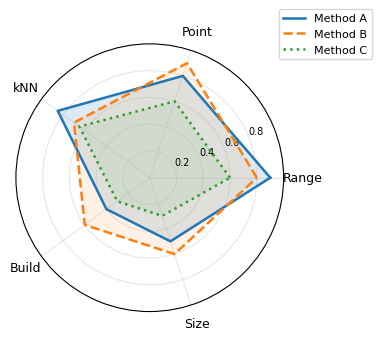

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# 指标
metrics = ["Range", "Point", "kNN", "Build", "Size"]
N = len(metrics)

# 示例分数：0~1，越大越好（你可以用 1/latency 或 rank-normalized）
method_A = [0.9, 0.8, 0.85, 0.4, 0.5]
method_B = [0.8, 0.9, 0.7, 0.6, 0.6]
method_C = [0.6, 0.6, 0.65, 0.3, 0.3]

angles = np.linspace(0, 2 * np.pi, N, endpoint=False)
angles = np.concatenate([angles, angles[:1]])  # 闭合多边形

def close(vals):
    return vals + vals[:1]

values_A = close(method_A)
values_B = close(method_B)
values_C = close(method_C)

fig, ax = plt.subplots(figsize=(4, 4), subplot_kw=dict(polar=True))

ax.plot(angles, values_A, linewidth=1.8, label="Method A")
ax.fill(angles, values_A, alpha=0.15)

ax.plot(angles, values_B, linewidth=1.8, linestyle="--", label="Method B")
ax.fill(angles, values_B, alpha=0.10)

ax.plot(angles, values_C, linewidth=1.8, linestyle=":", label="Method C")
ax.fill(angles, values_C, alpha=0.08)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(metrics, fontsize=9)

ax.set_yticks([0.2, 0.4, 0.6, 0.8])
ax.set_yticklabels(["0.2", "0.4", "0.6", "0.8"], fontsize=7)
ax.set_ylim(0, 1.0)

ax.grid(alpha=0.3)
ax.legend(loc="upper right", bbox_to_anchor=(1.35, 1.15), fontsize=8)
plt.tight_layout()
plt.show()
